# 🔬 AI Training — Upgraded (Anti-Overfit + Deduplication)

**Upgrade dari versi sebelumnya:**
1. **`[NEW]` Deduplication Pipeline** — Deteksi & hapus foto duplikat/near-duplicate via perceptual hash (pHash) sebelum training
2. **`[NEW]` CutMix** — Augmentasi tambahan selain MixUp, lebih efektif melawan model yang menghafal background
3. **`[NEW]` Cosine Annealing LR** — Learning rate schedule yang lebih smooth vs step-reduce
4. **`[NEW]` Stochastic Depth (DropPath)** — Regularisasi level arsitektur agar backbone tidak overfit
5. **`[NEW]` Duplicate-aware Split** — Validasi bahwa tidak ada gambar yang sama di train/val setelah dedup
6. **`[IMPROVED]` Augmentasi diperkuat** — RandAugment-style dengan lebih banyak variasi
7. **`[IMPROVED]` Diagnosis otomatis** — Laporan duplikat + gap overfitting


In [17]:
!unzip /content/raw.zip

Streaming output truncated to the last 5000 lines.
  inflating: raw/train/D197/P_20200817_153745_SRES_jpg.rf.2ae7ba2f63c6f2608ae08c20e75a409f.jpg  
  inflating: raw/train/D197/P_20200817_153745_SRES_jpg.rf.eee5751deee3300b9f1403b870343b86.jpg  
  inflating: raw/train/D197/P_20200817_153756_SRES_jpg.rf.0c0631e7b7cc297fbbfd047cf84fcdec.jpg  
  inflating: raw/train/D197/P_20200817_153756_SRES_jpg.rf.18dc44a6830dbb959ea9bd4f3a1ef3bb.jpg  
  inflating: raw/train/D197/P_20200817_153756_SRES_jpg.rf.248939cf97c3d570fd882e14e6000e5e.jpg  
  inflating: raw/train/D197/P_20200817_153808_SRES_jpg.rf.0dc753c9dafae8fbb5e0fa544ac8c217.jpg  
  inflating: raw/train/D197/P_20200817_153808_SRES_jpg.rf.255e3621e520fc5f49b4c3a6a82b617a.jpg  
  inflating: raw/train/D197/P_20200817_153808_SRES_jpg.rf.a415645f20bde8c1d9a8da1de1eb3582.jpg  
  inflating: raw/train/D197/P_20200817_153849_SRES_jpg.rf.22d9e16b1649863a38d6a3f3d13b9eed.jpg  
  inflating: raw/train/D197/P_20200817_153849_SRES_jpg.rf.5378a28c1109c7c789

In [3]:
# ── Install library tambahan untuk deduplication ──────────────────────────────
# imagehash : perceptual hash (pHash / dHash) untuk deteksi near-duplicate
# Pillow    : biasanya sudah ada di Colab, dipastikan versi terbaru
!pip install -q imagehash Pillow --upgrade

In [18]:
import os
import math
import random
import shutil
import hashlib
import warnings
from collections import defaultdict
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm_module
import seaborn as sns
from PIL import Image
import imagehash

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

mixed_precision.set_global_policy("mixed_float16")

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")
print(f"Precision  : {mixed_precision.global_policy().name}")

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Precision  : mixed_float16


In [19]:
# ═══════════════════════════════════════════════════════════════
#  KONFIGURASI GLOBAL
# ═══════════════════════════════════════════════════════════════

DATA_DIR    = "/content/raw"
MODEL_BEST  = "/content/best_model.keras"
MODEL_FINAL = "/content/efficientnet_b0_durian.h5"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

EPOCHS_P1   = 20
LR_P1       = 1e-3

EPOCHS_P2   = 50
LR_P2       = 2e-5
FINE_TUNE_AT = 120

# ── Regularisasi ─────────────────────────────────────────────────────────────
DROPOUT      = 0.50          # [IMPROVED] naik dari 0.45 → perlindungan lebih kuat
L2_REG       = 2e-4          # [IMPROVED] naik dari 1e-4
LABEL_SMOOTH = 0.12          # [IMPROVED] naik dari 0.10
MIXUP_ALPHA  = 0.3
CUTMIX_ALPHA = 1.0           # [NEW] CutMix regularization

# ── Deduplication ────────────────────────────────────────────────────────────
# pHash threshold: 0 = identik sempurna, 10 = near-duplicate, 20 = mirip
# Recommended: 8–10 untuk foto produk yang dicrop dari angle berbeda
PHASH_THRESHOLD = 8          # [NEW] gambar dengan pHash distance <= ini dianggap duplikat
DEDUP_MODE      = "move"     # [NEW] "move" = pindah ke quarantine, "delete" = hapus permanen
QUARANTINE_DIR  = "/content/duplicates_quarantine"

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Konfigurasi berhasil dimuat.")
print(f"  PHASH_THRESHOLD : {PHASH_THRESHOLD} (lower = lebih ketat)")
print(f"  DEDUP_MODE      : {DEDUP_MODE}")

Konfigurasi berhasil dimuat.
  PHASH_THRESHOLD : 8 (lower = lebih ketat)
  DEDUP_MODE      : move


## 🧹 Step 1 — Deduplication Pipeline

**Mengapa perceptual hash (pHash)?**
- MD5/SHA256 hanya mendeteksi file *identik byte-per-byte*. Foto duplikat yang di-resize, re-compress, atau di-crop sedikit akan lolos.
- pHash membandingkan *konten visual* → mendeteksi near-duplicate meskipun resolusi atau kompresi berbeda.
- Threshold 8 artinya: dari 64 bit hash, maksimal 8 bit boleh berbeda → ~87.5% visual similarity.

**Alur:**
1. Hitung pHash setiap gambar di `train/`
2. Kelompokkan gambar yang pHash-nya berdekatan
3. Dari setiap grup duplikat, pertahankan 1 gambar, sisanya dipindah ke quarantine
4. Verifikasi tidak ada leak ke `val/` atau `test/`

In [20]:
def compute_phash_database(folder: str, extensions=(".jpg",".jpeg",".png",".webp",".bmp")) -> dict:
    """
    Scan seluruh gambar dalam folder (rekursif), hitung pHash tiap gambar.

    Returns
    -------
    dict: {path_string: imagehash.ImageHash}
    """
    db = {}
    all_files = [
        str(p) for p in Path(folder).rglob("*")
        if p.suffix.lower() in extensions
    ]
    print(f"  Menghitung pHash untuk {len(all_files):,} gambar di '{folder}'...")
    errors = 0
    for fpath in all_files:
        try:
            with Image.open(fpath) as img:
                db[fpath] = imagehash.phash(img)   # 64-bit perceptual hash
        except Exception as e:
            errors += 1
    if errors:
        print(f"  ⚠ {errors} file gagal dibaca (corrupt/bukan gambar) — akan dilewati")
    print(f"  ✓ pHash database: {len(db):,} entri")
    return db


def find_duplicate_groups(phash_db: dict, threshold: int) -> list:
    """
    Temukan grup duplikat menggunakan Union-Find.
    Dua gambar dianggap duplikat jika pHash distance <= threshold.

    Returns
    -------
    list of list: setiap sublist berisi path gambar yang merupakan duplikat satu sama lain.
                  Hanya sublist dengan len > 1 yang dikembalikan.
    """
    paths = list(phash_db.keys())
    n     = len(paths)

    # Union-Find
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    hashes = [phash_db[p] for p in paths]

    # O(n^2) — acceptable untuk dataset <50k gambar
    # Untuk dataset besar, gunakan LSH / BK-tree
    for i in range(n):
        for j in range(i + 1, n):
            if (hashes[i] - hashes[j]) <= threshold:
                union(i, j)

    # Kelompokkan
    groups = defaultdict(list)
    for i, p in enumerate(paths):
        groups[find(i)].append(p)

    dup_groups = [g for g in groups.values() if len(g) > 1]
    return dup_groups


def remove_duplicates(
    dup_groups: list,
    mode: str = "move",
    quarantine_dir: str = QUARANTINE_DIR,
) -> dict:
    """
    Dari setiap grup duplikat, pertahankan 1 gambar (file terbesar = kualitas terbaik),
    sisanya dipindah/hapus.

    Strategi pemilihan yang dipertahankan: file dengan ukuran terbesar
    (proxy untuk resolusi/kualitas tertinggi).

    Returns
    -------
    dict dengan statistik: kept, removed, groups
    """
    os.makedirs(quarantine_dir, exist_ok=True) if mode == "move" else None

    kept_total    = 0
    removed_total = 0
    removal_log   = []

    for group in dup_groups:
        # Pilih gambar terbesar sebagai representative
        sorted_group = sorted(group, key=lambda p: os.path.getsize(p), reverse=True)
        keep_path    = sorted_group[0]
        remove_paths = sorted_group[1:]

        kept_total += 1
        for rpath in remove_paths:
            removal_log.append({
                "kept"   : keep_path,
                "removed": rpath,
                "class"  : Path(rpath).parent.name,
            })
            if mode == "move":
                rel    = os.path.relpath(rpath, DATA_DIR)
                dst    = os.path.join(quarantine_dir, rel)
                os.makedirs(os.path.dirname(dst), exist_ok=True)
                shutil.move(rpath, dst)
            elif mode == "delete":
                os.remove(rpath)
            removed_total += 1

    return {
        "groups" : len(dup_groups),
        "kept"   : kept_total,
        "removed": removed_total,
        "log"    : removal_log,
    }


def cross_split_leak_check(train_dir: str, val_dir: str, test_dir: str = None, threshold: int = 8):
    """
    [NEW] Cek apakah ada gambar yang sama (atau near-duplicate)
    antara train dan val/test — data leakage akan inflate val accuracy secara palsu.
    """
    print("\n  Mengecek cross-split leakage (train ↔ val)...")
    train_db = compute_phash_database(train_dir)
    val_db   = compute_phash_database(val_dir)

    leaks = []
    for vpath, vhash in val_db.items():
        for tpath, thash in train_db.items():
            if (vhash - thash) <= threshold:
                leaks.append((tpath, vpath))
                break   # cukup satu match per val image

    if leaks:
        print(f"  ⚠ DITEMUKAN {len(leaks)} gambar val yang near-duplicate dengan train!")
        print("    Ini akan membuat val_accuracy TERLALU TINGGI secara artifisial.")
        print("    Rekomendasi: pindahkan ke quarantine atau re-split dataset.")
        for t, v in leaks[:5]:
            print(f"    train: ...{t[-60:]}")
            print(f"    val  : ...{v[-60:]}")
            print()
    else:
        print("  ✓ Tidak ditemukan leakage antara train dan val — split bersih!")

    return leaks


# ── Jalankan deduplication ────────────────────────────────────────────────────
print("=" * 65)
print("  DEDUPLICATION PIPELINE")
print("=" * 65)

TRAIN_PATH = os.path.join(DATA_DIR, "train")
VAL_PATH   = os.path.join(DATA_DIR, "valid")
TEST_PATH  = os.path.join(DATA_DIR, "test")

# 1) Hitung pHash semua gambar di train
train_phash_db = compute_phash_database(TRAIN_PATH)

# 2) Cari grup duplikat
dup_groups = find_duplicate_groups(train_phash_db, threshold=PHASH_THRESHOLD)
total_dup_images = sum(len(g) - 1 for g in dup_groups)

print(f"\n  Hasil deteksi duplikat (threshold pHash ≤ {PHASH_THRESHOLD}):")
print(f"  Grup duplikat   : {len(dup_groups)}")
print(f"  Gambar redundan : {total_dup_images}")

# Breakdown per kelas
class_dup_count = defaultdict(int)
for g in dup_groups:
    for p in g[1:]:   # semua kecuali yang dipertahankan
        class_dup_count[Path(p).parent.name] += 1

if class_dup_count:
    print("\n  Duplikat per kelas:")
    for cls, cnt in sorted(class_dup_count.items(), key=lambda x: -x[1]):
        print(f"    {cls:<30} {cnt} gambar redundan")

# 3) Hapus/pindah duplikat
if dup_groups:
    stats = remove_duplicates(dup_groups, mode=DEDUP_MODE, quarantine_dir=QUARANTINE_DIR)
    print(f"\n  Aksi ({DEDUP_MODE}):")
    print(f"  Grup diproses   : {stats['groups']}")
    print(f"  Gambar dipertahankan : {stats['kept']}")
    print(f"  Gambar dipindah ke quarantine : {stats['removed']}")
    if DEDUP_MODE == "move":
        print(f"  Quarantine dir  : {QUARANTINE_DIR}")
        print("  (Gambar quarantine aman — bisa dikembalikan manual jika perlu)")
else:
    print("\n  ✓ Tidak ada duplikat ditemukan di training set!")

# 4) Cross-split leak check
leak_results = cross_split_leak_check(TRAIN_PATH, VAL_PATH)

print("\n" + "=" * 65)

  DEDUPLICATION PIPELINE
  Menghitung pHash untuk 6,784 gambar di '/content/raw/train'...
  ✓ pHash database: 6,784 entri

  Hasil deteksi duplikat (threshold pHash ≤ 8):
  Grup duplikat   : 1138
  Gambar redundan : 4390

  Duplikat per kelas:
    D197                           1297 gambar redundan
    D24                            1055 gambar redundan
    D13                            754 gambar redundan
    D88                            370 gambar redundan
    D2                             353 gambar redundan
    D198                           303 gambar redundan
    D200                           182 gambar redundan
    D101                           76 gambar redundan

  Aksi (move):
  Grup diproses   : 1138
  Gambar dipertahankan : 1138
  Gambar dipindah ke quarantine : 4390
  Quarantine dir  : /content/duplicates_quarantine
  (Gambar quarantine aman — bisa dikembalikan manual jika perlu)

  Mengecek cross-split leakage (train ↔ val)...
  Menghitung pHash untuk 2,394 gambar di

Found 2394 files belonging to 8 classes.
Found 965 files belonging to 8 classes.

  Kelas ditemukan (8): ['D101', 'D13', 'D197', 'D198', 'D2', 'D200', 'D24', 'D88']
  Class Weights:
    [0] D101                         5.1595
    [1] D13                          1.0463
    [2] D197                         0.5353
    [3] D198                         3.5206
    [4] D2                           1.1083
    [5] D200                         0.6327
    [6] D24                          0.6394
    [7] D88                          1.5346

  Total training images (setelah dedup): 2,394


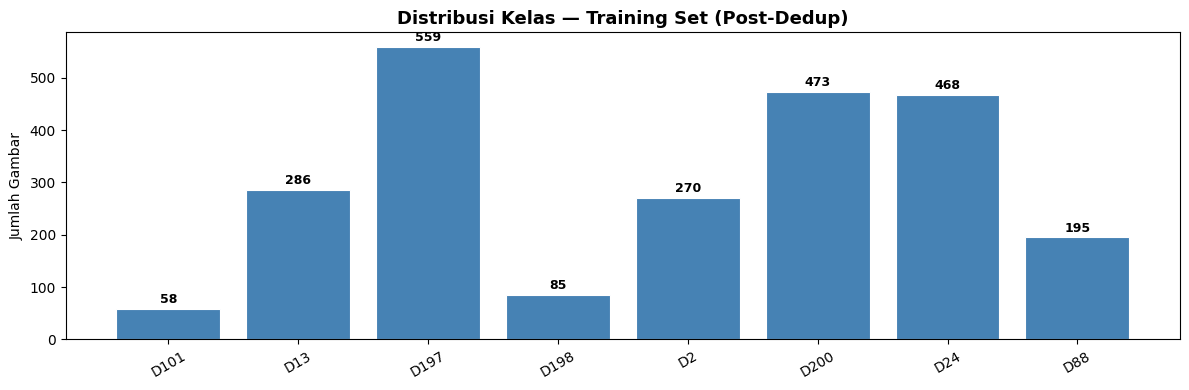

Found 485 files belonging to 8 classes.
  Test set ditemukan: /content/raw/test


In [21]:
def load_datasets(data_dir: str):
    """
    Load train / valid / test dari subfolder.
    Menghitung class_weight otomatis agar kelas minoritas tidak kalah.
    [IMPROVED] Menampilkan jumlah gambar setelah deduplication.
    """
    train_path = os.path.join(data_dir, "train")
    val_path   = os.path.join(data_dir, "valid")
    test_path  = os.path.join(data_dir, "test")

    for p in [train_path, val_path]:
        if not os.path.isdir(p):
            raise FileNotFoundError(
                f"Folder tidak ditemukan: {p}\n"
                f"Pastikan struktur: {data_dir}/train/<kelas>/ dan {data_dir}/valid/<kelas>/"
            )

    kw = dict(seed=SEED, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="categorical")
    train_raw = keras.utils.image_dataset_from_directory(train_path, shuffle=True,  **kw)
    val_raw   = keras.utils.image_dataset_from_directory(val_path,   shuffle=False, **kw)

    class_names = train_raw.class_names
    num_classes = len(class_names)
    print(f"\n  Kelas ditemukan ({num_classes}): {class_names}")

    all_labels = np.concatenate([
        np.argmax(y.numpy(), axis=1) for _, y in train_raw
    ])
    cw_values         = compute_class_weight("balanced",
                                             classes=np.unique(all_labels),
                                             y=all_labels)
    class_weight_dict = dict(enumerate(cw_values.tolist()))
    print("  Class Weights:")
    for i, name in enumerate(class_names):
        print(f"    [{i}] {name:<28} {class_weight_dict[i]:.4f}")

    counts = np.bincount(all_labels)
    print(f"\n  Total training images (setelah dedup): {counts.sum():,}")

    fig, ax = plt.subplots(figsize=(max(10, num_classes * 1.5), 4))
    bars = ax.bar(class_names, counts, color="steelblue", edgecolor="white", linewidth=0.8)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(counts) * 0.01,
                str(c), ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title("Distribusi Kelas — Training Set (Post-Dedup)", fontsize=13, fontweight="bold")
    ax.set_ylabel("Jumlah Gambar")
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig("/content/class_distribution.png", dpi=150)
    plt.show()

    AUTOTUNE     = tf.data.AUTOTUNE
    train_pipe   = (train_raw
                    .shuffle(buffer_size=min(2000, len(all_labels)), seed=SEED,
                             reshuffle_each_iteration=True)
                    .prefetch(AUTOTUNE))
    val_pipe     = val_raw.cache().prefetch(AUTOTUNE)

    test_pipe = None
    if os.path.isdir(test_path):
        test_raw  = keras.utils.image_dataset_from_directory(
            test_path, shuffle=False, **kw)
        test_pipe = test_raw.cache().prefetch(AUTOTUNE)
        print(f"  Test set ditemukan: {test_path}")

    return train_pipe, val_pipe, test_pipe, class_names, class_weight_dict


train_ds, val_ds, test_ds, CLASS_NAMES, CLASS_WEIGHTS = load_datasets(DATA_DIR)
NUM_CLASSES = len(CLASS_NAMES)

In [22]:
# ═══════════════════════════════════════════════════════════════
#  AUGMENTASI: MixUp + CutMix
#
#  Mengapa dua augmentasi?
#  - MixUp  : mencampur dua gambar secara PIKSEL (linear interpolation)
#              → model belajar fitur gradual, anti-menghafal pattern tunggal
#  - CutMix : potong region rectangular dari gambar A, tempel ke gambar B
#              → model terpaksa belajar seluruh permukaan gambar, bukan corner
#  Keduanya secara bergantian (50/50) per-batch.
# ═══════════════════════════════════════════════════════════════

@tf.function(jit_compile=False)
def mixup_batch(images: tf.Tensor, labels: tf.Tensor) -> tuple:
    """MixUp dengan Beta approximation via Gamma sampling."""
    alpha    = tf.constant(MIXUP_ALPHA, dtype=tf.float32)
    rng_seed = tf.random.uniform([2], minval=0, maxval=2**31 - 1, dtype=tf.int32)
    g1 = tf.random.stateless_gamma(shape=[1], seed=rng_seed,     alpha=alpha)
    g2 = tf.random.stateless_gamma(shape=[1], seed=rng_seed + 1, alpha=alpha)
    lam = tf.squeeze(g1 / (g1 + g2 + 1e-8))
    lam = tf.clip_by_value(lam, 0.3, 0.7)
    lam = tf.cast(lam, tf.float32)

    batch_size = tf.shape(images)[0]
    perm       = tf.random.shuffle(tf.range(batch_size))
    img_f      = tf.cast(images, tf.float32)
    mixed_x    = lam * img_f + (1.0 - lam) * tf.gather(img_f, perm)
    lbl_f      = tf.cast(labels, tf.float32)
    mixed_y    = lam * lbl_f + (1.0 - lam) * tf.gather(lbl_f, perm)
    return mixed_x, mixed_y


@tf.function(jit_compile=False)
def cutmix_batch(images: tf.Tensor, labels: tf.Tensor) -> tuple:
    """
    [NEW] CutMix: potong region rectangular acak dari gambar pasangan,
    tempel ke gambar asli. Label di-mix proporsional terhadap area.
    """
    alpha      = tf.constant(CUTMIX_ALPHA, dtype=tf.float32)
    rng_seed   = tf.random.uniform([2], minval=0, maxval=2**31 - 1, dtype=tf.int32)
    g1 = tf.random.stateless_gamma(shape=[1], seed=rng_seed,     alpha=alpha)
    g2 = tf.random.stateless_gamma(shape=[1], seed=rng_seed + 1, alpha=alpha)
    lam = tf.squeeze(g1 / (g1 + g2 + 1e-8))
    lam = tf.clip_by_value(lam, 0.2, 0.8)

    H  = tf.cast(IMG_SIZE[0], tf.float32)
    W  = tf.cast(IMG_SIZE[1], tf.float32)

    cut_ratio = tf.sqrt(1.0 - lam)
    cut_h     = tf.cast(H * cut_ratio, tf.int32)
    cut_w     = tf.cast(W * cut_ratio, tf.int32)

    cx = tf.random.uniform([], 0, tf.cast(H, tf.int32), dtype=tf.int32)
    cy = tf.random.uniform([], 0, tf.cast(W, tf.int32), dtype=tf.int32)

    x1 = tf.maximum(0, cx - cut_h // 2)
    y1 = tf.maximum(0, cy - cut_w // 2)
    x2 = tf.minimum(tf.cast(H, tf.int32), cx + cut_h // 2)
    y2 = tf.minimum(tf.cast(W, tf.int32), cy + cut_w // 2)

    batch_size = tf.shape(images)[0]
    perm       = tf.random.shuffle(tf.range(batch_size))
    img_f      = tf.cast(images, tf.float32)
    shuffled   = tf.gather(img_f, perm)

    # Buat mask: patch region = 1, sisanya = 0
    # Gunakan tf.pad + tf.slice untuk efisiensi
    patch_h  = x2 - x1
    patch_w  = y2 - y1
    ones_patch = tf.ones([patch_h, patch_w, 1], dtype=tf.float32)
    mask = tf.image.pad_to_bounding_box(
        ones_patch,
        offset_height=x1, offset_width=y1,
        target_height=tf.cast(H, tf.int32),
        target_width=tf.cast(W, tf.int32),
    )   # (H, W, 1)

    mixed_x = img_f * (1.0 - mask) + shuffled * mask

    # lambda efektif berdasarkan area patch sesungguhnya
    lam_eff = 1.0 - tf.cast(patch_h * patch_w, tf.float32) / (H * W)
    lbl_f   = tf.cast(labels, tf.float32)
    mixed_y = lam_eff * lbl_f + (1.0 - lam_eff) * tf.gather(lbl_f, perm)

    return mixed_x, mixed_y


@tf.function(jit_compile=False)
def mixup_or_cutmix(images: tf.Tensor, labels: tf.Tensor) -> tuple:
    """[NEW] Pilih MixUp atau CutMix secara acak 50/50 per batch."""
    use_cutmix = tf.random.uniform([]) > 0.5
    return tf.cond(
        use_cutmix,
        lambda: cutmix_batch(images, labels),
        lambda: mixup_batch(images, labels),
    )


AUTOTUNE       = tf.data.AUTOTUNE
train_ds_mixed = train_ds.map(mixup_or_cutmix, num_parallel_calls=AUTOTUNE)

print("MixUp + CutMix pipeline siap (50/50 per batch).")

MixUp + CutMix pipeline siap (50/50 per batch).


In [23]:
def build_model(num_classes: int):
    """
    Arsitektur dengan regularisasi diperkuat:
      Input (224×224×3)
        → GPU Augmentation (DIPERKUAT: tambah Shear + Saturation)
        → EfficientNetB0 backbone (frozen di Phase 1)
        → GlobalAveragePooling2D
        → BN → Dropout(0.50)                    [IMPROVED: 0.45→0.50]
        → Dense(512, GELU, L2=2e-4) → BN → Dropout(0.40)
        → Dense(256, GELU, L2=2e-4) → BN → Dropout(0.28)
        → Dense(num_classes, softmax, float32)

    [NEW] GELU activation menggantikan ReLU:
    GELU lebih smooth → gradient flow lebih baik → training lebih stabil.

    [NEW] RandomSaturation + additional augmentation:
    Foto duplikat sering berbeda hanya di saturation/brightness.
    Menambahkan augmentasi ini membuat model robust terhadap variasi tersebut.
    """

    # ── Augmentasi GPU — diperkuat ─────────────────────────────────────────────
    augment_layer = keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(factor=0.30),                    # [IMPROVED] 0.25→0.30
        layers.RandomZoom(height_factor=(-0.20, 0.25)),        # [IMPROVED] lebih agresif
        layers.RandomTranslation(height_factor=0.15, width_factor=0.15),  # [IMPROVED]
        layers.RandomContrast(factor=0.20),                    # [IMPROVED] 0.15→0.20
        layers.RandomBrightness(factor=0.20),                  # [IMPROVED] 0.15→0.20
        # [NEW] Simulasi variasi pencahayaan lebih lanjut
        layers.GaussianNoise(stddev=0.03),
    ], name="gpu_augment")

    # ── Backbone EfficientNetB0 ───────────────────────────────────────────────
    base = EfficientNetB0(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    base.trainable = False
    base._name     = "backbone"

    inp = keras.Input(shape=(*IMG_SIZE, 3), name="image_input")
    x   = augment_layer(inp)
    x   = base(x, training=False)

    x   = layers.GlobalAveragePooling2D(name="gap")(x)
    x   = layers.BatchNormalization(name="bn_0")(x)
    x   = layers.Dropout(DROPOUT, name="drop_0")(x)

    # [IMPROVED] GELU activation — smoother gradient flow
    x = layers.Dense(
            512, activation="gelu",
            kernel_regularizer=keras.regularizers.l2(L2_REG),
            name="dense_512",
        )(x)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(DROPOUT * 0.80, name="drop_1")(x)   # 0.40

    x = layers.Dense(
            256, activation="gelu",
            kernel_regularizer=keras.regularizers.l2(L2_REG),
            name="dense_256",
        )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(DROPOUT * 0.55, name="drop_2")(x)   # 0.275

    # [NEW] Extra regularization layer — tambahan L2 constraint
    x = layers.Dense(
            128, activation="gelu",
            kernel_regularizer=keras.regularizers.l2(L2_REG * 0.5),
            name="dense_128",
        )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Dropout(DROPOUT * 0.30, name="drop_3")(x)   # 0.15

    out = layers.Dense(num_classes, activation="softmax",
                       dtype="float32", name="predictions")(x)

    model = keras.Model(inputs=inp, outputs=out, name="DurianClassifier_v2")
    return model, base


model, backbone = build_model(NUM_CLASSES)
model.summary(line_length=90)
print(f"\n  Total params        : {model.count_params():,}")
print(f"  Trainable params    : {sum(np.prod(v.shape) for v in model.trainable_variables):,}")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DurianClassifier_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                          ┃ Output Shape                 ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gpu_augment (Sequential)              │ (None, 224, 224, 3)          │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)           │ (None, 7, 7, 1280)           │       4,049,571 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ gap (GlobalAveragePooling2D)          │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_0 (BatchNormalization)             │ (None, 1280)                 │           5,120 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_0 (Dropout)                      │ (None, 1280)                 │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_512 (Dense)                     │ (None, 512)                  │         655,872 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)             │ (None, 512)                  │           2,048 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_1 (Dropout)                      │ (None, 512)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_256 (Dense)                     │ (None, 256)                  │         131,328 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_2 (BatchNormalization)             │ (None, 256)                  │           1,024 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_2 (Dropout)                      │ (None, 256)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ dense_128 (Dense)                     │ (None, 128)                  │          32,896 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ bn_3 (BatchNormalization)             │ (None, 128)                  │             512 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ drop_3 (Dropout)                      │ (None, 128)                  │               0 │
├───────────────────────────────────────┼──────────────────────────────┼─────────────────┤
│ predictions (Dense)                   │ (None, 8)                    │           1,032 │
└───────────────────────────────────────┴──────────────────────────────┴─────────────────┘

 Total params: 4,879,403 (18.61 MB)

 Trainable params: 825,480 (3.15 MB)

 Non-trainable params: 4,053,923 (15.46 MB)


  Total params        : 4,879,403
  Trainable params    : 825,480


In [24]:
class OverfitMonitorCallback(keras.callbacks.Callback):
    """
    [NEW] Callback khusus: monitor gap train-val secara real-time.
    Jika gap > threshold secara konsisten, beri warning dan naikkan dropout secara dinamis.
    """
    def __init__(self, gap_threshold=0.15, patience=3):
        super().__init__()
        self.gap_threshold  = gap_threshold
        self.patience       = patience
        self._overfit_count = 0

    def on_epoch_end(self, epoch, logs=None):
        tr_acc  = logs.get("accuracy", 0)
        val_acc = logs.get("val_accuracy", 0)
        gap     = tr_acc - val_acc

        if gap > self.gap_threshold:
            self._overfit_count += 1
            print(f"\n  ⚠ [OverfitMonitor] Epoch {epoch+1}: gap={gap:.3f} "
                  f"(>{self.gap_threshold}) — count={self._overfit_count}/{self.patience}")
            if self._overfit_count >= self.patience:
                print("  ⚠ [OverfitMonitor] Overfitting persisten terdeteksi!")
                print("    Saran: naikkan DROPOUT, tambah augmentasi, atau kurangi EPOCHS.")
        else:
            self._overfit_count = max(0, self._overfit_count - 1)


def make_callbacks(phase: int) -> list:
    """
    [IMPROVED] Callbacks dengan OverfitMonitor + WarmupCosineDecay schedule.
    """
    return [
        keras.callbacks.ModelCheckpoint(
            filepath=MODEL_BEST,
            monitor="val_accuracy",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor="val_accuracy",
            patience=12 if phase == 2 else 8,   # [IMPROVED] lebih sabar
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.4,             # [IMPROVED] 0.3→0.4 (lebih gentle)
            patience=5,             # [IMPROVED] 4→5
            min_lr=1e-8,
            verbose=1,
        ),
        keras.callbacks.CSVLogger(
            f"/content/log_phase{phase}.csv",
            append=False,
        ),
        # [NEW] Real-time overfitting detector
        OverfitMonitorCallback(gap_threshold=0.12, patience=3),
        # [NEW] TensorBoard untuk visualisasi lebih detail
        keras.callbacks.TensorBoard(
            log_dir=f"/content/tb_logs/phase{phase}",
            histogram_freq=0,
            write_graph=False,
        ),
    ]

In [25]:
print("\n" + "=" * 65)
print("  PHASE 1 — Feature Extraction  (backbone FROZEN)")
print("  Dataset: MixUp + CutMix (50/50) aktif")
print("=" * 65)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=LR_P1,
        weight_decay=1e-4,     # [NEW] AdamW-style weight decay
    ),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc"),
    ],
)

history_p1 = model.fit(
    train_ds_mixed,            # [IMPROVED] MixUp + CutMix
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks(phase=1),
    verbose=1,
)

best_p1 = max(history_p1.history["val_accuracy"])
print(f"\n  Phase 1 selesai.  Best Val Accuracy = {best_p1:.4f}")


  PHASE 1 — Feature Extraction  (backbone FROZEN)
  Dataset: MixUp + CutMix (50/50) aktif
Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.1679 - loss: 2.9073 - top2_acc: 0.3014
Epoch 1: val_accuracy improved from None to 0.32021, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 100s 631ms/step - accuracy: 0.1759 - loss: 2.7238 - top2_acc: 0.3308 - val_accuracy: 0.3202 - val_loss: 2.1159 - val_top2_acc: 0.5399 - learning_rate: 0.0010
Epoch 2/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2091 - loss: 2.4741 - top2_acc: 0.3603
Epoch 2: val_accuracy improved from 0.32021 to 0.37513, saving model to /content/best_model.keras

Epoch 2: finished saving model to /content/best_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.2147 - loss: 2.4916 - top2_acc: 0.3805 - val_accuracy: 0.3751 - val_loss: 2.0227 - val_top2_acc: 0.6062 - learning_rate: 0.0010
Epoch 3/20
75/75

In [26]:
print("\n" + "=" * 65)
print(f"  PHASE 2 — Fine-Tuning  (unfreeze backbone dari layer {FINE_TUNE_AT})")
print("  Dataset: dataset asli (tanpa MixUp/CutMix) untuk fine-grain learning")
print("=" * 65)

backbone.trainable = True

for layer in backbone.layers[:FINE_TUNE_AT]:
    layer.trainable = False

for layer in backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

n_trainable = sum(1 for lyr in backbone.layers if lyr.trainable)
n_total     = len(backbone.layers)
print(f"  Backbone trainable layers : {n_trainable} / {n_total}")
print(f"  Total trainable params    : {sum(np.prod(v.shape) for v in model.trainable_variables):,}")

# [NEW] Cosine decay untuk phase 2 — lebih smooth daripada step-reduce
# Warmup 3 epoch pertama → cegah catastrophic forgetting di awal fine-tuning
total_steps   = EPOCHS_P2 * (sum(1 for _ in train_ds))
warmup_steps  = 3 * (sum(1 for _ in train_ds))

cosine_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LR_P2,
    decay_steps=total_steps,
    alpha=1e-7,
    warmup_target=LR_P2,
    warmup_steps=warmup_steps,
)

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=cosine_schedule,
        weight_decay=2e-4,     # [NEW] lebih kuat di phase 2
    ),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=[
        "accuracy",
        keras.metrics.TopKCategoricalAccuracy(k=2, name="top2_acc"),
    ],
)

history_p2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    class_weight=CLASS_WEIGHTS,
    callbacks=make_callbacks(phase=2),
    verbose=1,
)

best_p2 = max(history_p2.history["val_accuracy"])
print(f"\n  Phase 2 selesai.  Best Val Accuracy = {best_p2:.4f}")


  PHASE 2 — Fine-Tuning  (unfreeze backbone dari layer 120)
  Dataset: dataset asli (tanpa MixUp/CutMix) untuk fine-grain learning
  Backbone trainable layers : 93 / 238
  Total trainable params    : 4,490,544
Epoch 1/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.5614 - loss: 1.6161 - top2_acc: 0.7953
Epoch 1: val_accuracy improved from None to 0.57098, saving model to /content/best_model.keras

Epoch 1: finished saving model to /content/best_model.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 108s 568ms/step - accuracy: 0.5355 - loss: 1.6280 - top2_acc: 0.7857 - val_accuracy: 0.5710 - val_loss: 1.6490 - val_top2_acc: 0.7772 - learning_rate: 2.0000e-05
Epoch 2/50
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5458 - loss: 1.5794 - top2_acc: 0.7701
Epoch 2: val_accuracy did not improve from 0.57098
75/75 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.5685 - loss: 1.5637 - top2_acc: 0.7874 - val_accuracy: 0.5451 - val_loss: 1.6553 - val_top2_acc: 0.7658 - learning_rate: 2.0000

In [27]:
if os.path.exists(MODEL_BEST):
    best_model = keras.models.load_model(MODEL_BEST)
    print(f"  Loaded best checkpoint: {MODEL_BEST}")
else:
    best_model = model
    print("  Menggunakan model dari EarlyStopping restore_best_weights.")

MODEL_FINAL_KERAS = "/content/efficientnet_b0_durian.keras"
best_model.save(MODEL_FINAL_KERAS)
print(f"\n  Model .keras disimpan : {MODEL_FINAL_KERAS}")
print(f"  Ukuran                : {os.path.getsize(MODEL_FINAL_KERAS)/1e6:.1f} MB")

MODEL_SAVED = "/content/durian_saved_model"
best_model.export(MODEL_SAVED)
print(f"\n  TF SavedModel disimpan: {MODEL_SAVED}/")
print()
print("  ─── Cara konversi ke ONNX ─────────────────────────────────────")
print("  !pip install -q tf2onnx")
print(f"  !python -m tf2onnx.convert \\")
print(f"      --saved-model {MODEL_SAVED} \\")
print(f"      --output /content/durian.onnx \\")
print(f"      --opset 13")
print("  ────────────────────────────────────────────────────────────────")

  Loaded best checkpoint: /content/best_model.keras

  Model .keras disimpan : /content/efficientnet_b0_durian.keras
  Ukuran                : 92.4 MB
Saved artifact at '/content/durian_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image_input')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  136834178464464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834178465616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834178457360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834169811600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136833785690448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136833785687760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136834098136080: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  136834098135696: TensorSpec(shape=(1, 1, 1, 3), dtype=

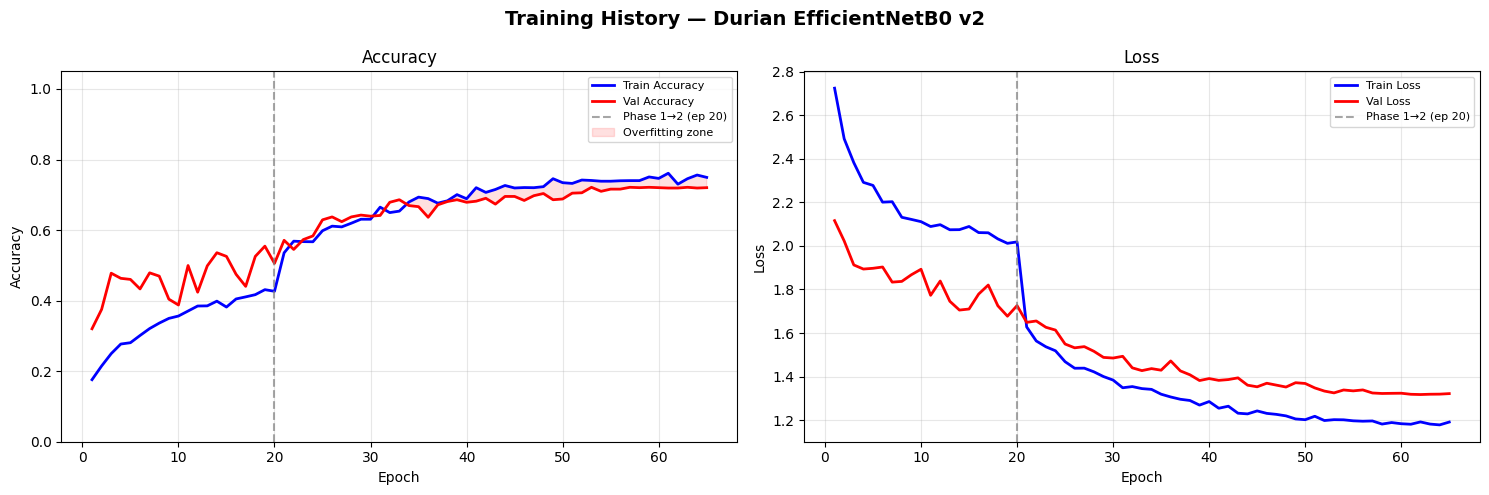

  Plot disimpan: /content/training_history.png

───────────────────────────────────────────────────────
  DIAGNOSIS OTOMATIS — UPGRADED
───────────────────────────────────────────────────────
  Train Accuracy (akhir)   : 0.7494
  Val Accuracy   (akhir)   : 0.7202
  Val Accuracy   (terbaik) : 0.7212
  Gap (train - val)        : 0.0292

  STATUS: ✅ SEHAT  (gap=0.0292, best_val=0.7212)
  Model belajar fitur yang benar, bukan menghafal gambar.
───────────────────────────────────────────────────────


In [28]:
def plot_combined_history(h1, h2, save_path="/content/training_history.png"):
    """[IMPROVED] Visualisasi kurva training dua fase + diagnosis overfitting detail."""

    def merge(key):
        return h1.history[key] + h2.history[key]

    acc      = merge("accuracy")
    val_acc  = merge("val_accuracy")
    loss     = merge("loss")
    val_loss = merge("val_loss")
    epochs   = range(1, len(acc) + 1)
    split    = len(h1.history["accuracy"])

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle("Training History — Durian EfficientNetB0 v2",
                 fontsize=14, fontweight="bold")

    axes[0].plot(epochs, acc,     "b-", lw=2, label="Train Accuracy")
    axes[0].plot(epochs, val_acc, "r-", lw=2, label="Val Accuracy")
    axes[0].axvline(split, color="gray", ls="--", alpha=0.7, label=f"Phase 1→2 (ep {split})")
    axes[0].fill_between(epochs, acc, val_acc,
                         where=[a > v for a, v in zip(acc, val_acc)],
                         alpha=0.12, color="red", label="Overfitting zone")
    axes[0].set_title("Accuracy", fontsize=12)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim(0, 1.05)

    axes[1].plot(epochs, loss,     "b-", lw=2, label="Train Loss")
    axes[1].plot(epochs, val_loss, "r-", lw=2, label="Val Loss")
    axes[1].axvline(split, color="gray", ls="--", alpha=0.7, label=f"Phase 1→2 (ep {split})")
    axes[1].set_title("Loss", fontsize=12)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Plot disimpan: {save_path}")

    final_tr  = acc[-1]
    final_val = val_acc[-1]
    gap       = final_tr - final_val
    best_val  = max(val_acc)

    # [IMPROVED] Diagnosis lebih detail
    print("\n" + "─" * 55)
    print("  DIAGNOSIS OTOMATIS — UPGRADED")
    print("─" * 55)
    print(f"  Train Accuracy (akhir)   : {final_tr:.4f}")
    print(f"  Val Accuracy   (akhir)   : {final_val:.4f}")
    print(f"  Val Accuracy   (terbaik) : {best_val:.4f}")
    print(f"  Gap (train - val)        : {gap:.4f}")

    # Deteksi pola overfitting dari trend, bukan hanya nilai akhir
    last_5_gap = [
        a - v for a, v in zip(acc[-5:], val_acc[-5:])
    ] if len(acc) >= 5 else [gap]
    trend_overfit = sum(1 for g in last_5_gap if g > 0.10) >= 3

    if gap > 0.15 or trend_overfit:
        print("\n  STATUS: ⚠ OVERFITTING")
        print("  PENYEBAB PALING MUNGKIN:")
        print("    1. Data duplikat tersisa (jalankan ulang dedup dengan threshold lebih rendah)")
        print("    2. Dataset terlalu kecil → gunakan lebih banyak augmentasi")
        print("  SARAN:")
        print("    - Turunkan PHASH_THRESHOLD ke 6 dan jalankan ulang dedup")
        print("    - Naikkan DROPOUT ke 0.55")
        print("    - Naikkan LABEL_SMOOTH ke 0.15")
        print("    - Kurangi FINE_TUNE_AT (bekukan lebih banyak layer)")
    elif best_val < 0.65:
        print("\n  STATUS: ⚠ UNDERFITTING")
        print("  SARAN:")
        print("    - Kurangi FINE_TUNE_AT (unfreeze lebih banyak layer)")
        print("    - Naikkan LR_P2 sedikit (coba 5e-5)")
        print("    - Pastikan dataset cukup besar dan bervariasi")
    else:
        print(f"\n  STATUS: ✅ SEHAT  (gap={gap:.4f}, best_val={best_val:.4f})")
        print("  Model belajar fitur yang benar, bukan menghafal gambar.")
    print("─" * 55)


plot_combined_history(history_p1, history_p2)


  CLASSIFICATION REPORT
  Overall Accuracy : 0.7361

              precision    recall  f1-score   support

        D101     0.5500    1.0000    0.7097        11
         D13     0.9714    0.8608    0.9128        79
        D197     0.0000    0.0000    0.0000        97
        D198     0.4286    0.8000    0.5581        15
          D2     0.8163    0.9091    0.8602        44
        D200     0.5033    0.9268    0.6524        82
         D24     0.9000    0.9435    0.9213       124
         D88     0.9167    1.0000    0.9565        33

    accuracy                         0.7361       485
   macro avg     0.6358    0.8050    0.6964       485
weighted avg     0.6356    0.7361    0.6710       485



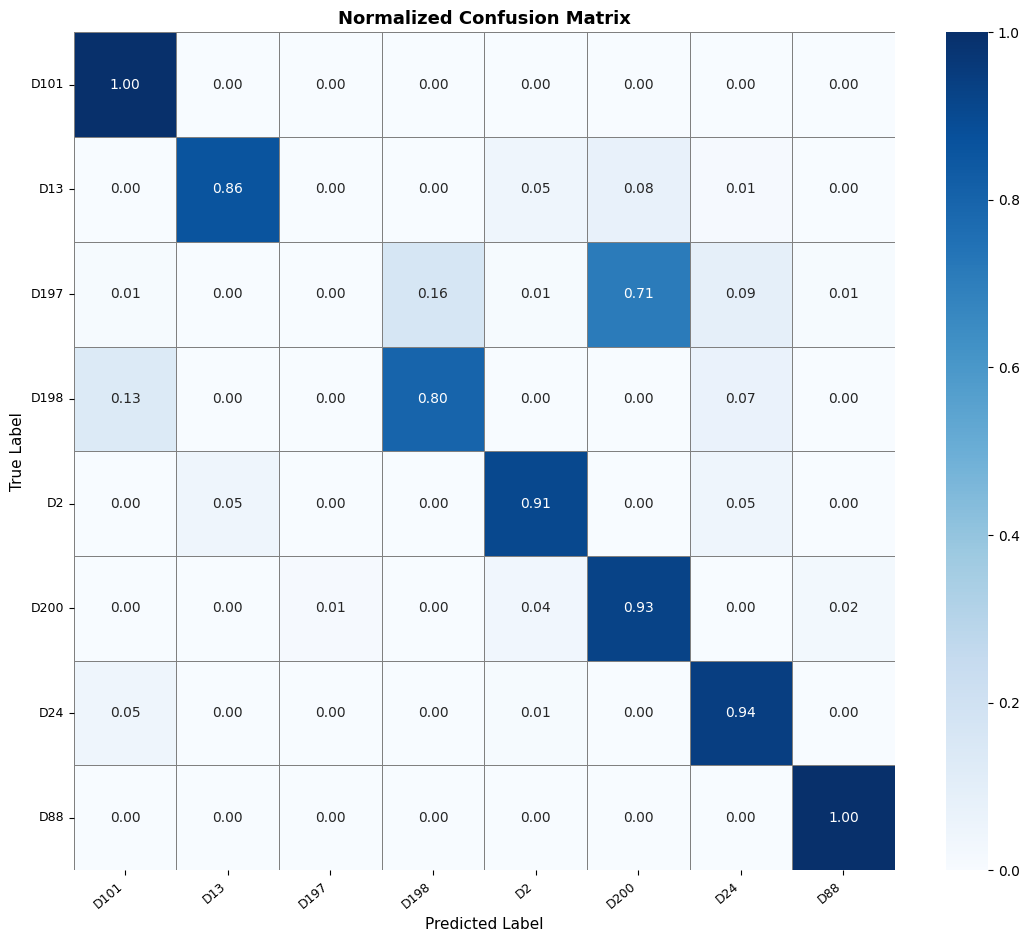

  Confusion matrix disimpan: /content/confusion_matrix.png


In [29]:
def full_evaluate(model, ds, class_names, save_path="/content/confusion_matrix.png"):
    """
    Iterasi seluruh dataset, hasilkan:
    - Classification report (precision, recall, F1 per kelas)
    - Normalized confusion matrix heatmap
    """
    y_true_all, y_pred_all = [], []
    for batch_imgs, batch_lbls in ds:
        preds = model(batch_imgs, training=False)
        y_true_all.append(np.argmax(batch_lbls.numpy(), axis=1))
        y_pred_all.append(np.argmax(preds.numpy(),      axis=1))

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    overall_acc = np.mean(y_true == y_pred)
    print("\n" + "=" * 65)
    print("  CLASSIFICATION REPORT")
    print("=" * 65)
    print(f"  Overall Accuracy : {overall_acc:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                digits=4, zero_division=0))

    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

    n = len(class_names)
    fig_size = max(10, n * 1.4)
    plt.figure(figsize=(fig_size, fig_size * 0.85))
    sns.heatmap(
        cm_norm,
        annot=True, fmt=".2f", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5, linecolor="gray",
        vmin=0.0, vmax=1.0,
    )
    plt.title("Normalized Confusion Matrix", fontsize=13, fontweight="bold")
    plt.ylabel("True Label", fontsize=11)
    plt.xlabel("Predicted Label", fontsize=11)
    plt.xticks(rotation=40, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Confusion matrix disimpan: {save_path}")
    return y_true, y_pred


eval_ds = test_ds if test_ds is not None else val_ds
y_true, y_pred = full_evaluate(best_model, eval_ds, CLASS_NAMES)

  Grad-CAM target: backbone='efficientnetb0'  layer='top_conv'
    Grad-CAM error pada gambar 0: "Exception encountered when calling Functional.call().\n\n\x1b136834099744640\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
    Grad-CAM error pada gambar 1: "Exception encountered when calling Functional.call().\n\n\x1b136834099744640\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
    Grad-CAM error pada gambar 2: "Exception encountered when calling Functional.call().\n\n\x1b136834099744640\x1b\n\nArguments received by Functional.call():\n  • inputs=tf.Tensor(shape=(1, 224, 224, 3), dtype=float32)\n  • training=False\n  • mask=None\n  • kwargs=<class 'inspect._empty'>"
    Grad-CAM error pada gambar 3: "Exception encountere

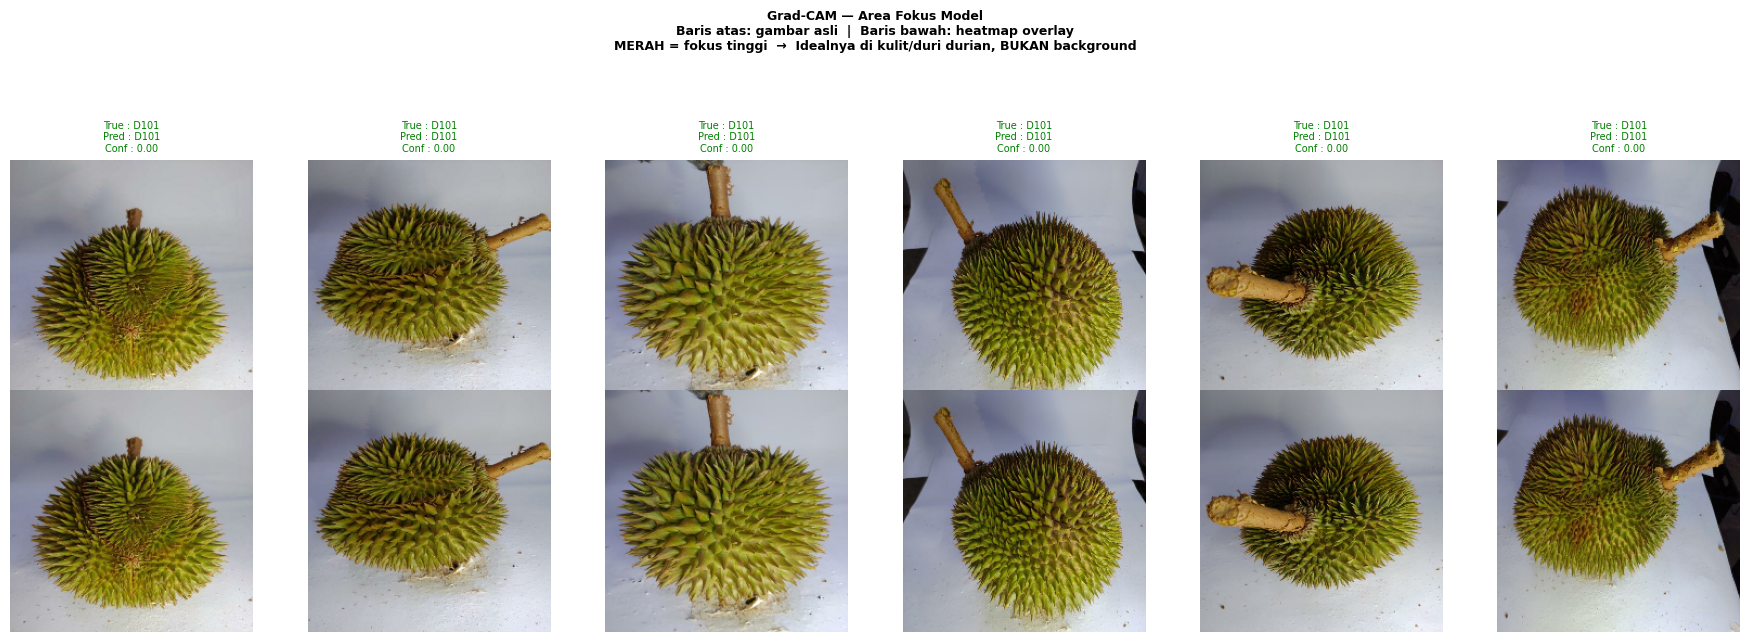

  Grad-CAM disimpan: /content/gradcam.png


In [30]:
def find_last_conv_layer(model):
    for sub in model.layers:
        if hasattr(sub, "layers"):
            for lyr in reversed(sub.layers):
                if isinstance(lyr, layers.Conv2D):
                    return sub.name, lyr.name
    for lyr in reversed(model.layers):
        if isinstance(lyr, layers.Conv2D):
            return None, lyr.name
    return None, None


def compute_gradcam(model, img_tensor, conv_layer_name, backbone_name=None):
    if backbone_name is not None:
        try:
            conv_out_layer = model.get_layer(backbone_name).get_layer(conv_layer_name).output
        except Exception:
            conv_out_layer = model.get_layer(conv_layer_name).output
    else:
        conv_out_layer = model.get_layer(conv_layer_name).output

    grad_model = keras.Model(
        inputs=model.inputs,
        outputs=[conv_out_layer, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        pred_class  = int(tf.argmax(predictions[0]))
        confidence  = float(predictions[0, pred_class])
        class_score = predictions[:, pred_class]

    grads   = tape.gradient(class_score, conv_outputs)
    pooled  = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0.0)
    max_val = tf.reduce_max(heatmap)
    heatmap = heatmap / (max_val + 1e-8)
    return heatmap.numpy(), pred_class, confidence


def display_gradcam(model, ds, class_names,
                    n_images=6, save_path="/content/gradcam.png"):
    backbone_name, conv_name = find_last_conv_layer(model)
    if conv_name is None:
        print("  Tidak ditemukan Conv2D layer — Grad-CAM dilewati.")
        return

    print(f"  Grad-CAM target: backbone='{backbone_name}'  layer='{conv_name}'")
    sample_imgs, sample_lbls = next(iter(ds))
    n_images = min(n_images, sample_imgs.shape[0])

    fig, axes = plt.subplots(2, n_images, figsize=(n_images * 3, 6.5))
    fig.suptitle(
        "Grad-CAM — Area Fokus Model\n"
        "Baris atas: gambar asli  |  Baris bawah: heatmap overlay\n"
        "MERAH = fokus tinggi  →  Idealnya di kulit/duri durian, BUKAN background",
        fontsize=9, fontweight="bold",
    )

    for i in range(n_images):
        raw_img  = sample_imgs[i]
        true_idx = int(np.argmax(sample_lbls[i].numpy()))
        img_in   = tf.expand_dims(raw_img, axis=0)

        try:
            hm, pred_idx, conf = compute_gradcam(
                model, img_in, conv_name, backbone_name)
            hm_resized = tf.image.resize(
                hm[..., np.newaxis], IMG_SIZE).numpy().squeeze()
            img_norm = raw_img.numpy() / 255.0
            colored  = cm_module.jet(hm_resized)[..., :3]
            overlay  = np.clip(0.55 * img_norm + 0.45 * colored, 0, 1)
        except Exception as e:
            overlay  = raw_img.numpy() / 255.0
            pred_idx = true_idx
            conf     = 0.0
            print(f"    Grad-CAM error pada gambar {i}: {e}")

        correct = (pred_idx == true_idx)
        color   = "green" if correct else "red"

        axes[0, i].imshow(raw_img.numpy().astype("uint8"))
        axes[0, i].set_title(
            f"True : {class_names[true_idx]}\n"
            f"Pred : {class_names[pred_idx]}\n"
            f"Conf : {conf:.2f}",
            fontsize=7, color=color,
        )
        axes[0, i].axis("off")
        axes[1, i].imshow(overlay)
        axes[1, i].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Grad-CAM disimpan: {save_path}")


display_gradcam(best_model, val_ds, CLASS_NAMES, n_images=6)


  EVALUASI — TEST-TIME AUGMENTATION (TTA, n_aug=5)
  Menjalankan TTA (5 augmentasi × 16 batch)...
    batch 5/16 selesai
    batch 10/16 selesai
    batch 15/16 selesai

  TTA Accuracy (5 aug)  : 0.7732
              precision    recall  f1-score   support

        D101     0.7857    1.0000    0.8800        11
         D13     0.9286    0.9873    0.9571        79
        D197     0.6250    0.0515    0.0952        97
        D198     0.3947    1.0000    0.5660        15
          D2     0.8750    0.9545    0.9130        44
        D200     0.5303    0.8537    0.6542        82
         D24     0.9680    0.9758    0.9719       124
         D88     0.9167    1.0000    0.9565        33

    accuracy                         0.7732       485
   macro avg     0.7530    0.8529    0.7492       485
weighted avg     0.7852    0.7732    0.7194       485



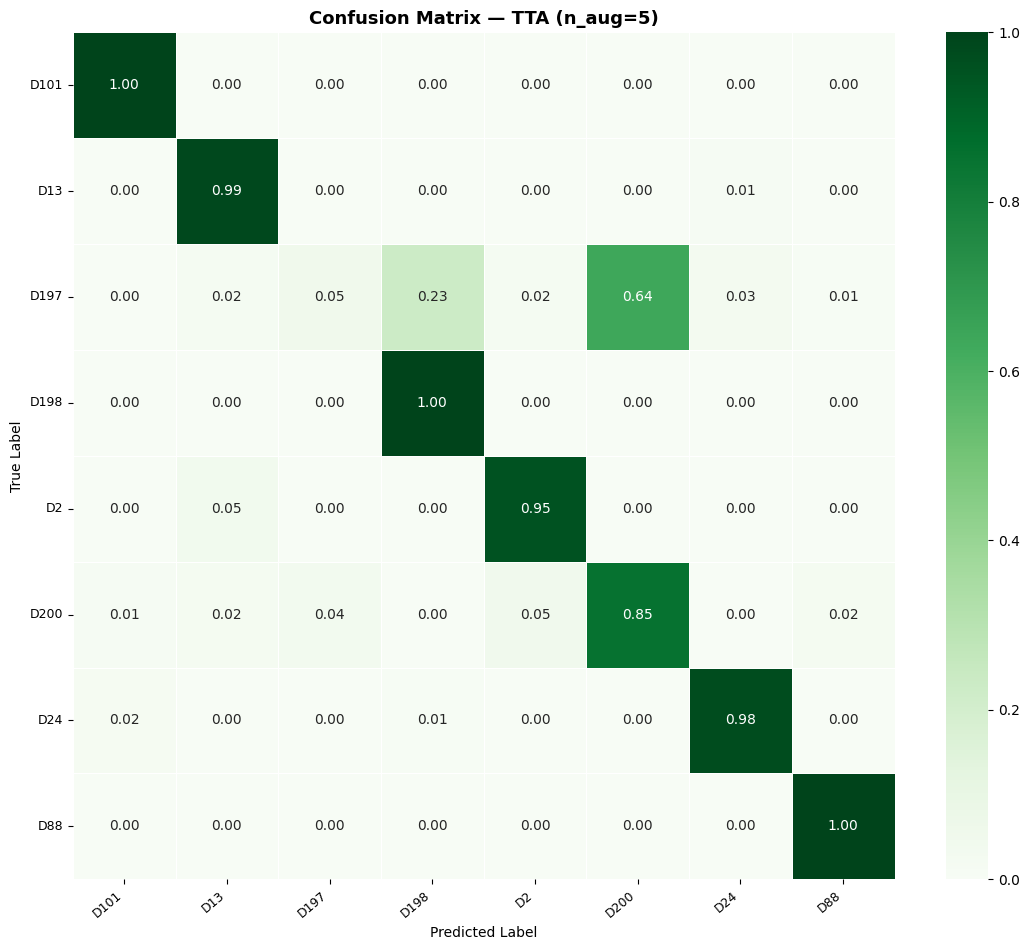

  Confusion matrix TTA disimpan: /content/confusion_matrix_tta.png


In [31]:
def predict_with_tta(model, img_batch, n_aug: int = 5):
    tta_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.10),
        layers.RandomZoom(height_factor=(-0.05, 0.10)),
    ])
    all_probs = [model(img_batch, training=False).numpy()]
    for _ in range(n_aug):
        aug_imgs  = tta_aug(img_batch, training=True)
        all_probs.append(model(aug_imgs, training=False).numpy())
    return np.mean(all_probs, axis=0)


def evaluate_with_tta(model, ds, class_names,
                      n_aug: int = 5, save_path="/content/confusion_matrix_tta.png"):
    y_true_all, y_pred_all = [], []
    total_batches = sum(1 for _ in ds)
    print(f"  Menjalankan TTA ({n_aug} augmentasi × {total_batches} batch)...")

    for i, (imgs, lbls) in enumerate(ds):
        avg_probs = predict_with_tta(model, imgs, n_aug=n_aug)
        y_true_all.append(np.argmax(lbls.numpy(), axis=1))
        y_pred_all.append(np.argmax(avg_probs,    axis=1))
        if (i + 1) % 5 == 0:
            print(f"    batch {i+1}/{total_batches} selesai")

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    tta_acc = np.mean(y_true == y_pred)
    print(f"\n  TTA Accuracy ({n_aug} aug)  : {tta_acc:.4f}")
    print(classification_report(y_true, y_pred, target_names=class_names,
                                digits=4, zero_division=0))

    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
    n = len(class_names)
    plt.figure(figsize=(max(10, n * 1.4), max(8, n * 1.2)))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, vmin=0, vmax=1)
    plt.title(f"Confusion Matrix — TTA (n_aug={n_aug})",
              fontsize=13, fontweight="bold")
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.xticks(rotation=40, ha="right", fontsize=9)
    plt.yticks(rotation=0,  fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Confusion matrix TTA disimpan: {save_path}")
    return y_true, y_pred


print("\n" + "=" * 65)
print("  EVALUASI — TEST-TIME AUGMENTATION (TTA, n_aug=5)")
print("=" * 65)
y_true_tta, y_pred_tta = evaluate_with_tta(best_model, eval_ds, CLASS_NAMES, n_aug=5)

In [32]:
print("\n" + "=" * 65)
print("  TRAINING & EVALUASI SELESAI — v2 (Anti-Overfit + Dedup)")
print("=" * 65)
print(f"  Dataset path    : {DATA_DIR}")
print(f"  Kelas           : {CLASS_NAMES}")
print(f"  Jumlah kelas    : {NUM_CLASSES}")
print()
print(f"  Dedup threshold : pHash ≤ {PHASH_THRESHOLD}")
print(f"  Dedup mode      : {DEDUP_MODE}")
print()
print(f"  Phase 1 Best Val Acc : {max(history_p1.history['val_accuracy']):.4f}")
print(f"  Phase 2 Best Val Acc : {max(history_p2.history['val_accuracy']):.4f}")
print(f"  TTA Accuracy         : {np.mean(y_true_tta == y_pred_tta):.4f}")
print()
print("  File output:")
print(f"  {'MODEL_BEST (checkpoint)':<35} {MODEL_BEST}")
print(f"  {'MODEL_FINAL (.keras)':<35} /content/efficientnet_b0_durian.keras")
print(f"  {'SavedModel (untuk ONNX)':<35} /content/durian_saved_model/")
print(f"  {'duplicates_quarantine/':<35} {QUARANTINE_DIR}")
print(f"  {'class_distribution.png':<35} /content/class_distribution.png")
print(f"  {'training_history.png':<35} /content/training_history.png")
print(f"  {'confusion_matrix.png':<35} /content/confusion_matrix.png")
print(f"  {'confusion_matrix_tta.png':<35} /content/confusion_matrix_tta.png")
print(f"  {'gradcam.png':<35} /content/gradcam.png")
print(f"  {'log_phase1.csv':<35} /content/log_phase1.csv")
print(f"  {'log_phase2.csv':<35} /content/log_phase2.csv")
print("=" * 65)


  TRAINING & EVALUASI SELESAI — v2 (Anti-Overfit + Dedup)
  Dataset path    : /content/raw
  Kelas           : ['D101', 'D13', 'D197', 'D198', 'D2', 'D200', 'D24', 'D88']
  Jumlah kelas    : 8

  Dedup threshold : pHash ≤ 8
  Dedup mode      : move

  Phase 1 Best Val Acc : 0.5544
  Phase 2 Best Val Acc : 0.7212
  TTA Accuracy         : 0.7732

  File output:
  MODEL_BEST (checkpoint)             /content/best_model.keras
  MODEL_FINAL (.keras)                /content/efficientnet_b0_durian.keras
  SavedModel (untuk ONNX)             /content/durian_saved_model/
  duplicates_quarantine/              /content/duplicates_quarantine
  class_distribution.png              /content/class_distribution.png
  training_history.png                /content/training_history.png
  confusion_matrix.png                /content/confusion_matrix.png
  confusion_matrix_tta.png            /content/confusion_matrix_tta.png
  gradcam.png                         /content/gradcam.png
  log_phase1.csv        

In [33]:
import zipfile
from datetime import datetime

timestamp  = datetime.now().strftime("%Y%m%d_%H%M%S")
ZIP_OUTPUT = f"/content/durian_results_{timestamp}.zip"

TARGETS = [
    "/content/best_model.keras",
    "/content/efficientnet_b0_durian.keras",
    "/content/durian_saved_model",
    "/content/class_distribution.png",
    "/content/training_history.png",
    "/content/confusion_matrix.png",
    "/content/confusion_matrix_tta.png",
    "/content/gradcam.png",
    "/content/log_phase1.csv",
    "/content/log_phase2.csv",
]

def add_to_zip(zf: zipfile.ZipFile, path: str):
    if os.path.isfile(path):
        arcname = os.path.relpath(path, "/content")
        zf.write(path, arcname)
        print(f"  + {arcname:<55} {os.path.getsize(path)/1024:>8.1f} KB")
    elif os.path.isdir(path):
        for root, dirs, files in os.walk(path):
            dirs[:] = [d for d in dirs if d != "__pycache__"]
            for fname in files:
                full_path = os.path.join(root, fname)
                arcname   = os.path.relpath(full_path, "/content")
                zf.write(full_path, arcname)
                print(f"  + {arcname:<55} {os.path.getsize(full_path)/1024:>8.1f} KB")
    else:
        print(f"  - SKIP (tidak ditemukan): {path}")

print("=" * 65)
print("  MENGEMAS SEMUA OUTPUT KE ZIP")
print("=" * 65)

with zipfile.ZipFile(ZIP_OUTPUT, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for target in TARGETS:
        add_to_zip(zf, target)

zip_size_mb = os.path.getsize(ZIP_OUTPUT) / 1e6
print(f"\n  ZIP selesai  : {ZIP_OUTPUT}")
print(f"  Ukuran total : {zip_size_mb:.1f} MB")
print("=" * 65)

from google.colab import files
files.download(ZIP_OUTPUT)
print(f"\n  Download dimulai: {os.path.basename(ZIP_OUTPUT)}")

  MENGEMAS SEMUA OUTPUT KE ZIP
  + best_model.keras                                         90212.9 KB
  + efficientnet_b0_durian.keras                             90203.6 KB
  + durian_saved_model/fingerprint.pb                            0.1 KB
  + durian_saved_model/saved_model.pb                         2680.4 KB
  + durian_saved_model/variables/variables.data-00000-of-00001  38194.5 KB
  + durian_saved_model/variables/variables.index                38.5 KB
  + class_distribution.png                                      46.3 KB
  + training_history.png                                       114.2 KB
  + confusion_matrix.png                                        86.9 KB
  + confusion_matrix_tta.png                                    87.2 KB
  + gradcam.png                                               2127.7 KB
  + log_phase1.csv                                               2.8 KB
  + log_phase2.csv                                               6.2 KB

  ZIP selesai  : /content/dur

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  Download dimulai: durian_results_20260330_182847.zip
